# ESMRMB 2026 analysis: ROI-variant comparison

This notebook reconstructs the quantitative panels from the ESMRMB 2026 abstract using the current `master.long.parquet` tables. Its scientific question is whether the derived microstructural observables are stable when the same diffusion data are summarized with different ROI definitions (`plain`, `erode1`, `sket1`, and future variants). Acquisition selection, physical constants, gradient correction, fitting models, bounds, and plotting rules are held fixed so that the ROI extraction is the intended changing factor.

Implemented analogues:

1. Paired OGSE signal fits and the resampled $\Delta M_{fit}(g)=M_{N=8}(g)-M_{N=4}(g)$ on one common corrected-gradient grid.
2. NOGSE-like contrast versus center filter length $l_{c,f}$, with $\tau_c(T_D)$ insets.
3. PGSE-derived macroscopic tortuosity $\alpha$ and NOGSE-derived transition time $\delta$ across regions.
4. $\delta$ versus $\alpha$ across regions, directions, subjects, and variants.

The complete dependency chain is

$$\text{master signals} \rightarrow \text{gradient correction} \rightarrow \text{paired signal fits} \rightarrow \text{common-grid resampling} \rightarrow \Delta M_{fit}(g) \rightarrow (l_{c,f},\tau_{c,peak}) \rightarrow \delta.$$

In parallel, projected PGSE diffusivities provide the macroscopic coefficient $\alpha$. The last panels compare $\alpha$ and $\delta$ across subjects, ROIs, directions, and extraction variants. The discovery step recognizes future analysis tags automatically. Dataset-specific choices remain in one configuration cell so the same workflow can be used for phantoms after their master tables are available.

This is an analysis and visualization notebook, not an ROI-generation notebook. It assumes that signal extraction, tensor rotation, gradient calibration, and alpha-summary generation have already completed for every selected variant.

## 1. Imports, provenance, and data model

Run the notebook from any directory inside the project. The helper below finds the project root without relying on a user-specific absolute path. All scientific calculations are implemented in `src/presentation_analysis/abstract_figures.py`; the notebook supplies configuration, displays intermediate QC, and exports reproducible artifacts.

The long master table is the source of truth. A signal row is identified by acquisition metadata (`subj`, `sheet`, $T_D$, $N$, source file and gradient step), spatial metadata (`roi`, rotated `direction`), statistic (`avg` or `std`), and processing provenance (`variant`, `analysis_tag`, `row_kind`). `signal_rotated` means the diffusion tensor and signal directions have already been expressed relative to the local ROI/fiber frame. The analysis never infers missing rows and never merges subjects or acquisition sheets.

Main units used below: $T_D$, $\tau_c$, $c$, and $\delta$ are in ms; gradient strength is in mT/m; $D_0$ is stored in m$^2$/ms; and $l_{c,f}$ is displayed in $\mu$m. Normalized signal and contrast are dimensionless.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'Data-BIDS').is_dir() and (candidate / 'repos' / 'signal_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the Project-Balseiro-Microstructure root.')


PROJECT_ROOT = find_project_root()
REPO_ROOT = PROJECT_ROOT / 'repos' / 'signal_analysis'
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Reload local helpers so Run All also picks up code changes in an existing kernel.
import presentation_analysis.abstract_figures as _abstract_figures
import presentation_analysis as _presentation_analysis
importlib.reload(_abstract_figures)
importlib.reload(_presentation_analysis)

from presentation_analysis import (
    CC_ROIS,
    aggregate_alpha,
    build_resampled_contrasts,
    compare_with_reference,
    compare_with_reference_metrics,
    discover_analysis_runs,
    export_all_signal_contrast_panels,
    fit_tc_pseudohuber,
    load_alpha_summaries,
    load_masters,
    master_qc_summary,
    merge_alpha_delta,
    plot_alpha_delta_scatter,
    plot_contrast_lcf_grid,
    plot_metric_comparison,
    plot_signal_contrast_example,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 80)
PROJECT_ROOT

PosixPath('/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure')

## 2. Configuration

Choose `DATASET = 'brains'` or `DATASET = 'phantoms'`. Each dataset has explicit defaults for DWI level, reference diffusivity, ROIs, directions, and example panels. Set any override to `None` to use those defaults and the dimensions found in the master table. `VARIANTS = None` discovers current and future variants automatically.

The reference diffusivity $D_0$ is a physical prior used by the restricted-signal model and by the gradient-to-length transformation; it is not refitted independently for every ROI in this notebook. Consequently, brain and phantom values must remain explicit and should be reviewed before the phantom analysis is finalized. The $N=8$ and $N=4$ selection defines the two encoding waveforms whose difference is studied.

`SAVE_OUTPUTS` controls persistent tables and presentation figures. `EXPORT_ALL_SIGNAL_CONTRAST_PANELS` controls the exhaustive Section 6 gallery. With its default `True`, executing the notebook creates one image for every observed subject/sheet/ROI/direction/$T_D$ combination, not only the interactive example.

In [2]:
# Dataset profiles: keep acquisition-specific physics and selections explicit.
DATASET_PROFILES = {
    'brains': {
        'dwi_level': 'den_gr-topup',
        'd0_m2_ms': 3.2e-12,
        'rois': list(CC_ROIS),
        'directions': ['long', 'tra'],
        'example_subject': 'ADBN',
        'example_roi': 'PostCC',
        'example_direction': 'long',
    },
    'phantoms': {
        'dwi_level': 'raw',
        'd0_m2_ms': 2.3e-12,
        'rois': None,               # None uses every ROI/sample found in the phantom master
        'directions': None,         # None prefers long/tra, then uses every available direction
        'example_subject': None,
        'example_roi': None,
        'example_direction': None,
    },
}

# Data selection
DATASET = 'brains'                 # Change only this to 'phantoms' for the future phantom masters
SEQUENCE = 'ogse'
DWI_LEVEL_OVERRIDE = None           # e.g. 'den_gr-topup' or 'raw'
VARIANTS = None                    # None discovers all variants; or e.g. ['plain', 'erode1', 'sket1']
REFERENCE_VARIANT = None            # None prefers plain and otherwise uses the first available variant

# Contrast definition from the abstract
N_HIGH = 8
N_LOW = 4
DIRECTION_OVERRIDE = None           # None uses the dataset profile/master table
ROI_OVERRIDE = None                 # None uses the dataset profile/master table
APPLY_GRADIENT_CORRECTION = True
RESAMPLE_GRID_SIZE = 1000
SIGNAL_TC_BOUNDS_MS = (0.1, 10000.0)
RICIAN_C_BOUNDS = (0.0, 2.0)

# Example panels analogous to Figures 1b and 2
EXAMPLE_SUBJECT_OVERRIDE = None
EXAMPLE_ROI_OVERRIDE = None
EXAMPLE_DIRECTION_OVERRIDE = None
EXAMPLE_TD_MS = 143.4
LCF_LIMITS_UM = (3.0, 12.0)

# Pseudo-Huber configuration used in the abstract analysis
EXCLUDE_TD_MS = (76.0,)
TD_RANGE_MS = (50.0, 250.0)
C_BOUNDS_MS = (0.0, 10.0)
DELTA_BOUNDS_MS = (1e-6, 10000.0)

# Transparent display-only QC. All fits remain in the exported audit tables.
MIN_PSEUDOHUBER_R2_FOR_SUMMARY = 0.50
EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY = True

# Exhaustive Section 6 export: one panel per subject/sheet/ROI/direction/TD combination.
EXPORT_ALL_SIGNAL_CONTRAST_PANELS = True
CLEAN_BATCH_PANEL_DIR = True       # Remove stale PNGs/manifest only inside the gallery folder
BATCH_PANEL_DPI = 180             # Lower than the presentation figures to control disk usage
BATCH_PROGRESS_EVERY = 25

SAVE_OUTPUTS = True

if DATASET not in DATASET_PROFILES:
    raise ValueError(f'Unknown DATASET={DATASET!r}; choose one of {list(DATASET_PROFILES)}.')
PROFILE = DATASET_PROFILES[DATASET]
DWI_LEVEL = DWI_LEVEL_OVERRIDE or PROFILE['dwi_level']
D0_REFERENCE_M2_MS = PROFILE['d0_m2_ms']
OUTPUT_DIR = (
    REPO_ROOT / 'notebooks' / 'outputs' / 'esmrmb_variant_comparison' / DATASET / DWI_LEVEL
)
OUTPUT_DIR

PosixPath('/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup')

## 3. Discover variants and audit comparability

The analysis tag is parsed as `<DWI level>--<ROI variant>`. Newly created variants appear automatically when `VARIANTS` is `None`. Every table is loaded with its variant and dataset provenance attached before concatenation.

For the current corpus-callosum analysis, `plain` is the original labeled CC mask, `erode1` erodes the whole CC by one voxel and then restores the surviving original labels, and `sket1` is the CC skeleton dilated by one voxel and clipped to the original CC. Erosion reduces boundary partial volume but can delete thin subregions; the skeletonized band emphasizes the medial core but samples fewer and spatially different voxels. Therefore agreement across variants supports robustness to ROI geometry, whereas disagreement can reflect partial volume, SNR/voxel-count changes, or true spatial heterogeneity—it is not automatically an error in one method. Future variant names are treated as new provenance levels; their biological interpretation must come from the segmentation procedure that created them.

A fair segmentation comparison requires more than a similar total row count. Coverage is therefore compared on the complete logical signal key. `missing_rows` reports reference observations that cannot be matched in a candidate variant, while `extra_rows` reports the reverse. A missing ROI can be a legitimate consequence of erosion or skeletonization, but it reduces the paired sample and must remain visible. Exact or logical duplicates indicate an ingestion problem and should be resolved upstream.

Later group summaries use only matched subject/ROI/direction keys. No signal, fit, ROI, or subject is imputed to make variants appear balanced.

In [3]:
runs = discover_analysis_runs(
    PROJECT_ROOT,
    dataset=DATASET,
    sequence=SEQUENCE,
    dwi_level=DWI_LEVEL,
)
available_variants = runs['variant'].tolist()
if VARIANTS is None:
    preferred_order = ['plain', 'erode1', 'sket1']
    selected_variants = [v for v in preferred_order if v in available_variants]
    selected_variants += [v for v in available_variants if v not in selected_variants]
else:
    selected_variants = list(VARIANTS)
if REFERENCE_VARIANT is None:
    REFERENCE_VARIANT = 'plain' if 'plain' in selected_variants else selected_variants[0]
if REFERENCE_VARIANT not in selected_variants:
    raise ValueError(f'Reference variant {REFERENCE_VARIANT!r} is not selected.')

display(runs[['dwi_level', 'variant', 'dataset', 'master_path']])
print('Selected variants:', selected_variants)

,dwi_level,variant,dataset,master_path
0,den_gr-topup,erode1,brains,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
1,den_gr-topup,plain,brains,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...
2,den_gr-topup,sket1,brains,/mnt/storage/tier2/MUMI-EXT-001/mumi-data/Proj...


Selected variants: ['plain', 'erode1', 'sket1']


In [4]:
masters = load_masters(runs, selected_variants)
alpha_raw = load_alpha_summaries(runs, selected_variants)
alpha_subject = aggregate_alpha(alpha_raw)

# Resolve analysis dimensions from the profile and the loaded master table.
rotated = masters.loc[masters['row_kind'].eq('signal_rotated')].copy()
available_rois = sorted(rotated['roi'].dropna().astype(str).unique())
available_directions = sorted(rotated['direction'].dropna().astype(str).unique())
requested_rois = ROI_OVERRIDE if ROI_OVERRIDE is not None else PROFILE['rois']
requested_directions = (
    DIRECTION_OVERRIDE if DIRECTION_OVERRIDE is not None else PROFILE['directions']
)
analysis_rois = (
    available_rois
    if requested_rois is None
    else [roi for roi in requested_rois if roi in available_rois]
)
if requested_directions is None:
    preferred_directions = [d for d in ['long', 'tra'] if d in available_directions]
    analysis_directions = preferred_directions or available_directions
else:
    analysis_directions = [d for d in requested_directions if d in available_directions]
if not analysis_rois or not analysis_directions:
    raise ValueError(
        f'No usable dimensions. Available ROIs={available_rois}; directions={available_directions}.'
    )

EXAMPLE_SUBJECT = EXAMPLE_SUBJECT_OVERRIDE or PROFILE['example_subject']
EXAMPLE_ROI = EXAMPLE_ROI_OVERRIDE or PROFILE['example_roi']
EXAMPLE_DIRECTION = (
    EXAMPLE_DIRECTION_OVERRIDE or PROFILE['example_direction']
)

qc = master_qc_summary(masters)
coverage, missing_rows = compare_with_reference(
    masters,
    reference_variant=REFERENCE_VARIANT,
    row_kind='signal_rotated',
)
display(qc)
display(coverage)
print('Analysis ROIs:', analysis_rois)
print('Analysis directions:', analysis_directions)
print(
    'Requested example:',
    EXAMPLE_SUBJECT or 'auto',
    EXAMPLE_ROI or 'auto',
    EXAMPLE_DIRECTION or 'auto',
    EXAMPLE_TD_MS,
)

,variant,rows,signal_rows,rotated_rows,subjects,sheets,sources,exact_duplicates,logical_duplicates
0,plain,275520,217920,57600,6,10,92,0,0
1,erode1,275520,217920,57600,6,10,92,0,0
2,sket1,273582,216390,57192,6,10,92,0,0


,variant,reference,reference_rows,matched_rows,missing_rows,extra_rows,coverage_percent
0,plain,plain,57600,57600,0,0,100.000000
1,erode1,plain,57600,57600,0,0,100.000000
2,sket1,plain,57600,57192,408,0,99.291667


Analysis ROIs: ['AntCC', 'MidAntCC', 'CentralCC', 'MidPostCC', 'PostCC']
Analysis directions: ['long', 'tra']
Requested example: ADBN PostCC long 143.4


,variant,subj,roi,direction,missing_rows
0,sket1,ARVE,AntCC,eig1,18
1,sket1,ARVE,AntCC,eig2,18
2,sket1,ARVE,AntCC,eig3,18
3,sket1,ARVE,AntCC,long,18
4,sket1,ARVE,AntCC,tra,18
5,sket1,ARVE,AntCC,x,18
6,sket1,ARVE,AntCC,y,18
7,sket1,ARVE,AntCC,z,18
8,sket1,BRAIN,MidPostCC,eig1,33
9,sket1,BRAIN,MidPostCC,eig2,33


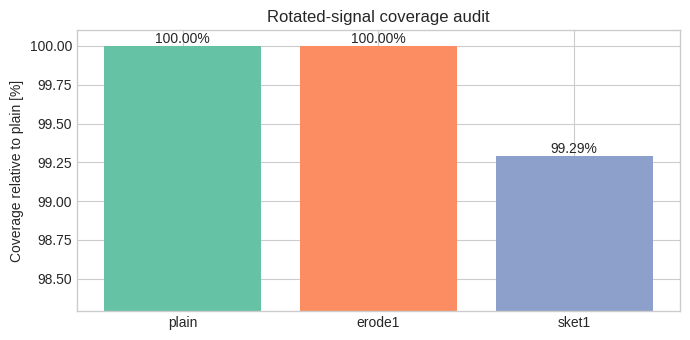

In [5]:
if missing_rows.empty:
    print('Every selected variant has the same rotated-row coverage as the reference.')
else:
    missing_summary = (
        missing_rows.groupby(['variant', 'subj', 'roi', 'direction'], as_index=False)
        .size()
        .rename(columns={'size': 'missing_rows'})
    )
    display(missing_summary)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(coverage['variant'], coverage['coverage_percent'], color=plt.cm.Set2.colors[:len(coverage)])
ax.set_ylim(max(0, coverage['coverage_percent'].min() - 1), 100.1)
ax.set_ylabel(f'Coverage relative to {REFERENCE_VARIANT} [%]')
ax.set_title('Rotated-signal coverage audit')
for index, value in enumerate(coverage['coverage_percent']):
    ax.text(index, value, f'{value:.2f}%', ha='center', va='bottom')
fig.tight_layout()
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / '00_coverage_audit.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Gradient correction, signal fitting, resampling, and contrast

### 4.1 Why the gradient axis must be corrected first

The nominal gradient is not assumed to be the physical gradient experienced by the sample. Upstream calibration uses a reference ROI and computes

$$f_g=\sqrt{D_{0,\mathrm{NOGSE}}/\langle D_{0,\mathrm{monoexp}}\rangle}, \qquad g_{corr}=f_g g_{nominal}.$$

The factor may depend on acquisition, direction, and $N$. It is already stored in each master row as `grad_correction_factor`; this notebook applies it but does not estimate it again. Because the corrected $N=8$ and $N=4$ gradient samples generally do not coincide, subtracting rows with the same acquisition index would evaluate the two signals at different physical gradients and would not define $\Delta M(g)$ at a common $g$.

### 4.2 Restricted signal and normalized Rician floor

For each subject/sheet/ROI/direction/$T_D$ group, the two branches are fitted jointly. The clean restricted model can be summarized as

$$M_{rest}=M_0\exp[-\phi_{SE}-\phi_N+\phi_{cross}],$$

where the attenuation terms encode the finite correlation time $\tau_c$, waveform timing, $N$, corrected gradient, and fixed $D_0$. Here the waveform interval is $x=T_D/N$. Magnitude-MRI noise produces a non-zero floor, represented by

$$M(g,N,T_D)=\frac{\sqrt{M_{rest}(g,N,T_D)^2+C^2}}{\sqrt{1+C^2}}.$$

The denominator preserves $M(0)=1$ for normalized data. The fit has three free parameters: $\tau_{c,8}$, $\tau_{c,4}$, and one shared $C$. It fixes $M_0=1$ and the dataset-specific $D_0$. Sharing $C$ treats the two branches as measurements with a common magnitude-noise floor while allowing their effective correlation times to differ. The optimizer works in log space for positive $\tau_c$ values and reports branch-specific and combined $R^2$, RMSE, parameter errors, bounds, and status in `signal_pair_fit_summary.csv`.

### 4.3 Common-grid resampling

After fitting, both continuous models are evaluated on the same grid

$$g_j\in[0,\min(g_{8,max}^{corr},g_{4,max}^{corr})], \qquad j=1,\ldots,n_g,$$

and the contrast is finally computed as

$$\Delta M_{fit}(g_j)=M_{8,fit}(g_j)-M_{4,fit}(g_j).$$

Using only the overlap prevents the peak from being driven by extrapolation beyond one branch's measured range. The grid begins at zero, so both normalized fits equal one and $\Delta M_{fit}(0)=0$ by construction. `RESAMPLE_GRID_SIZE` controls numerical peak resolution; it does not add independent observations.

### 4.4 From the contrast peak to a filtered length and time

The sampled maximum gives $g_{peak}$. With $\gamma=267.5221900$ rad ms$^{-1}$ mT$^{-1}$ and the fixed $D_0$, the notebook uses

$$l_g=\left(\frac{2^{3/2}D_0}{\gamma g}\right)^{1/3}, \quad l_D=\sqrt{2D_0T_D}, \quad L_D=\frac{l_D}{l_g},$$

$$L_{c,f}=\left(\frac{3}{2}\right)^{1/4}L_D^{-1/2}, \quad l_{c,f}=L_{c,f}l_g, \quad \tau_{c,peak}=\frac{l_{c,f}^2}{2D_0}.$$

These are model-derived coordinates, not independently measured histological sizes. Their interpretation inherits the assumptions of the restricted model, the chosen $D_0$, the gradient calibration, and the peak-selection rule.

In [6]:
contrasts, contrast_fits = build_resampled_contrasts(
    masters,
    d0_m2_ms=D0_REFERENCE_M2_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    directions=analysis_directions,
    rois=analysis_rois,
    apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
    tc_bounds_ms=SIGNAL_TC_BOUNDS_MS,
    rician_c_bounds=RICIAN_C_BOUNDS,
    grid_size=RESAMPLE_GRID_SIZE,
)

contrast_fit_qc = (
    contrast_fits.groupby(['variant', 'ok'], as_index=False)
    .agg(curves=('td_ms', 'size'), median_r2=('r2', 'median'), median_rmse=('rmse', 'median'))
)
display(contrast_fit_qc)
display(
    contrast_fits.loc[contrast_fits['ok'].fillna(False)]
    .nsmallest(15, 'r2')[
        ['variant', 'subj', 'roi', 'direction', 'td_ms', 'r2_high', 'r2_low', 'r2', 'C']
    ]
)
print(f'Resampled contrast points: {len(contrasts):,}')
print(f'Signal pairs: {len(contrast_fits):,}; successful: {int(contrast_fits.ok.sum()):,}')

,variant,ok,curves,median_r2,median_rmse
0,erode1,True,250,0.978701,0.029290
1,plain,True,250,0.994512,0.019437
2,sket1,False,8,NaN,NaN
3,sket1,True,242,0.960688,0.037307


,variant,subj,roi,direction,td_ms,r2_high,r2_low,r2,C
658,sket1,LUDG,PostCC,tra,90.0,-4.492589,0.069870,-0.652361,2.000000e+00
720,sket1,SNVN,AntCC,tra,120.0,0.122162,-0.071569,0.127222,2.000000e+00
710,sket1,SNVN,AntCC,tra,90.0,-0.374082,-0.587286,0.190345,1.999756e+00
730,sket1,SNVN,AntCC,tra,143.4,-0.199779,0.422288,0.195707,1.125054e+00
596,sket1,BRAIN,PostCC,tra,120.0,0.634934,0.283507,0.414830,1.607189e-08
496,erode1,SNVN,MidPostCC,tra,210.0,0.334763,0.877112,0.644697,7.165810e-01
286,erode1,ADBN,MidPostCC,tra,210.0,0.413696,0.880970,0.673198,7.311750e-01
326,erode1,ARVE,MidPostCC,tra,210.0,0.711261,0.600098,0.697758,1.109270e+00
574,sket1,ARVE,MidPostCC,tra,210.0,0.711261,0.600098,0.697758,1.109270e+00
650,sket1,LUDG,AntCC,tra,90.0,0.547388,0.777441,0.710008,1.800761e-07


Resampled contrast points: 742,000
Signal pairs: 750; successful: 742


## 5. PGSE macroscopic coefficient and microscopic-to-macroscopic transition

### 5.1 Independent PGSE-derived constraint

The upstream alpha step uses tensor-projected diffusivities `D_proj` from rotated signal rows. At the configured b-value it averages the projected diffusivity across the available apparent diffusion times and normalizes it by a reference free diffusivity:

$$\alpha_{macro}=\frac{\langle D_{proj}\rangle}{D_{0,ref}}.$$

The summary spreadsheet carries the selected b-step/b-value, the number and range of apparent diffusion times, the mean and spread of $D_{proj}$, the reference $D_0$, and propagated uncertainty. If multiple acquisition sheets contribute the same subject/ROI/direction key, `aggregate_alpha` averages their estimates and propagates the reported independent errors. This quantity is determined before the NOGSE peak-transition fit and is held fixed there, which reduces parameter degeneracy.

### 5.2 Pseudo-Huber transition model

For each variant, subject, ROI, and direction, the peak correlation times across diffusion times are fitted with

$$\tau_c(T_D)=c+\alpha\delta\left[\sqrt{1+(T_D/\delta)^2}-1\right],$$

where $\alpha$ is fixed to the PGSE-derived value and $c$ and $\delta$ are fitted. The parameter $c$ is the short-time intercept and $\delta$ controls the crossover scale. The limiting behavior makes the role of the model clear:

$$T_D\ll\delta:\quad \tau_c\approx c+\frac{\alpha T_D^2}{2\delta},$$

$$T_D\gg\delta:\quad \tau_c\approx c+\alpha(T_D-\delta).$$

Thus the curve is smooth and approximately quadratic at short times, then approaches a line with slope $\alpha$. At least three retained $T_D$ values are required for the two free parameters. Times in `EXCLUDE_TD_MS` are explicitly omitted to reproduce the chosen analysis definition; the retained interval is controlled by `TD_RANGE_MS`.

Optimizer convergence is necessary but not sufficient. A solution at the $\delta$ upper bound usually means that the sampled time range did not identify the transition. The `presentation_ok` flag additionally applies the visible $R^2$ threshold and optional boundary exclusion only to summary plots. Every attempted fit, including failures and exclusions, remains in `pseudohuber_fit_summary.csv` and `pseudohuber_fit_exclusions.csv`.

In [7]:
tc_data, tc_summary = fit_tc_pseudohuber(
    contrast_fits,
    alpha_subject,
    exclude_td_ms=EXCLUDE_TD_MS,
    td_range_ms=TD_RANGE_MS,
    c_bounds_ms=C_BOUNDS_MS,
    delta_bounds_ms=DELTA_BOUNDS_MS,
)
tc_summary['at_delta_boundary'] = (
    pd.to_numeric(tc_summary['delta_ms'], errors='coerce') >= 0.999 * DELTA_BOUNDS_MS[1]
)
tc_summary['presentation_ok'] = (
    tc_summary['ok'].fillna(False)
    & (pd.to_numeric(tc_summary['r2'], errors='coerce') >= MIN_PSEUDOHUBER_R2_FOR_SUMMARY)
)
if EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY:
    tc_summary['presentation_ok'] &= ~tc_summary['at_delta_boundary']

transition_qc = (
    tc_summary.groupby('variant', as_index=False)
    .agg(
        attempted=('ok', 'size'),
        converged=('ok', 'sum'),
        presentation_valid=('presentation_ok', 'sum'),
        median_r2=('r2', 'median'),
        boundary_fits=('at_delta_boundary', 'sum'),
    )
)
display(transition_qc)

fit_exclusions = tc_summary[~tc_summary['presentation_ok']].copy()
if not fit_exclusions.empty:
    display(fit_exclusions[['variant', 'subj', 'roi', 'direction', 'n_td', 'delta_ms', 'r2', 'at_delta_boundary', 'message']])

,variant,attempted,converged,presentation_valid,median_r2,boundary_fits
0,erode1,60,60,55,0.965674,3
1,plain,60,60,60,0.977180,0
2,sket1,59,55,48,0.905402,1


,variant,subj,roi,direction,n_td,delta_ms,r2,at_delta_boundary,message
3,erode1,ADBN,CentralCC,tra,4,1604.907289,0.323287,False,`ftol` termination condition is satisfied.
17,erode1,ARVE,MidPostCC,tra,3,10000.000000,-0.002112,True,`gtol` termination condition is satisfied.
43,erode1,MBBL,CentralCC,tra,4,991.998939,0.496015,False,`ftol` termination condition is satisfied.
53,erode1,SNVN,CentralCC,tra,4,9999.999719,0.337690,True,`gtol` termination condition is satisfied.
57,erode1,SNVN,MidPostCC,tra,4,10000.000000,-0.358958,True,`gtol` termination condition is satisfied.
126,sket1,ADBN,MidPostCC,long,4,1888.323736,0.356570,False,`ftol` termination condition is satisfied.
130,sket1,ARVE,AntCC,long,2,NaN,NaN,False,Fewer than three diffusion times
131,sket1,ARVE,AntCC,tra,2,NaN,NaN,False,Fewer than three diffusion times
137,sket1,ARVE,MidPostCC,tra,3,986.007567,0.171049,False,`ftol` termination condition is satisfied.
139,sket1,ARVE,PostCC,tra,3,2188.806896,0.014810,False,`ftol` termination condition is satisfied.


In [8]:
metrics = merge_alpha_delta(alpha_subject, tc_summary)
metrics = metrics.merge(
    tc_summary[['variant', 'subj', 'roi', 'direction', 'presentation_ok', 'at_delta_boundary']],
    on=['variant', 'subj', 'roi', 'direction'],
    how='left',
    validate='one_to_one',
)
metrics.insert(0, 'dataset', DATASET)
metrics_for_plots = metrics[metrics['presentation_ok'].fillna(False)].copy()
display(metrics_for_plots.head())

,dataset,variant,subj,roi,direction,alpha_macro,alpha_macro_error,alpha_n_sheets,delta_ms,delta_error_ms,c_ms,r2,n_td,ok,presentation_ok,at_delta_boundary
0,brains,plain,ADBN,AntCC,long,0.278379,0.032675,1,1211.032840,344.558224,5.161179,0.864725,4,True,True,False
1,brains,plain,ADBN,AntCC,tra,0.186273,0.007574,1,696.457255,65.654781,4.742175,0.984264,4,True,True,False
2,brains,plain,ADBN,CentralCC,long,0.316747,0.014574,1,1648.432244,572.104593,5.051476,0.808721,4,True,True,False
3,brains,plain,ADBN,CentralCC,tra,0.155560,0.026969,1,664.278616,131.535564,4.234847,0.934669,4,True,True,False
4,brains,plain,ADBN,MidAntCC,long,0.310729,0.024568,1,1566.711775,543.850860,5.284358,0.808959,4,True,True,False


## 6. Figure 1b analogue: paired signal fits and resampled contrast

Each row is one ROI-extraction variant. In the left column, markers are the measured $N=8$ and $N=4$ normalized signals plotted at their own corrected gradients; solid lines are the simultaneous restricted-model fits with a shared Rician $C$. The data points need not share x-coordinates. In the right column, the green curve is the difference of those fitted signals after evaluation on one common corrected-gradient grid; the star marks its sampled maximum.

This visual is the most direct diagnostic of the analysis chain. Check that both branches cover a useful gradient range, that the fitted lines follow the measurements without a bound-driven shape, that the contrast starts at zero, and that the peak lies inside the shared range rather than at its boundary. A blank variant row means that this exact acquisition combination was missing or its paired fit failed; it is deliberately not hidden.

The first cell below keeps one convenient interactive example. The next cell exports the same two-column comparison for **every** subject, acquisition sheet, ROI, direction, and diffusion time found in the fit audit.

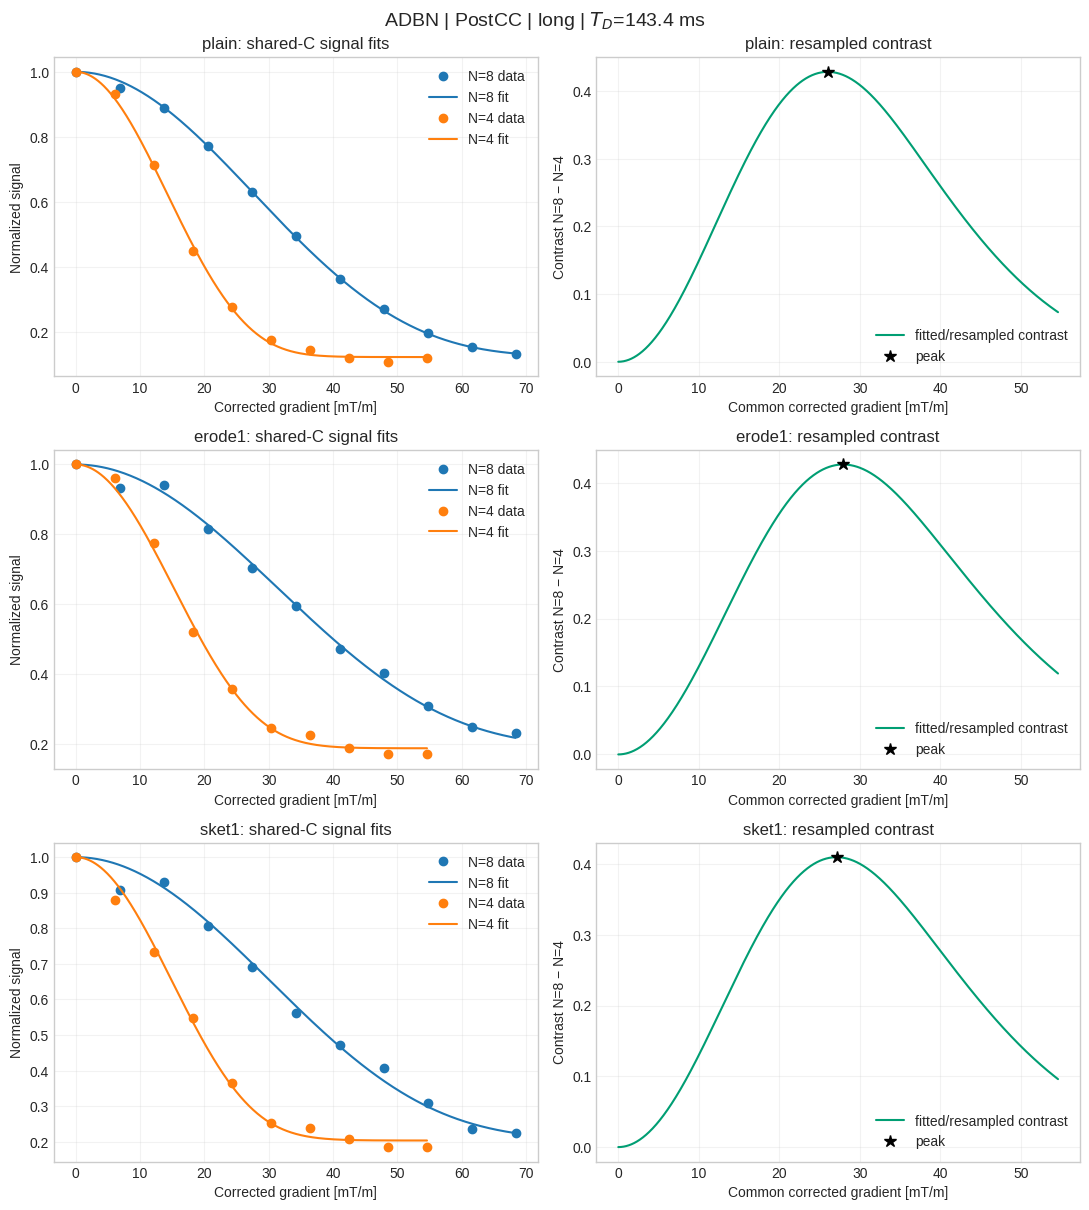

Exported 25/250 signal/contrast panels
Exported 50/250 signal/contrast panels
Exported 75/250 signal/contrast panels
Exported 100/250 signal/contrast panels
Exported 125/250 signal/contrast panels
Exported 150/250 signal/contrast panels
Exported 175/250 signal/contrast panels
Exported 200/250 signal/contrast panels
Exported 225/250 signal/contrast panels
Exported 250/250 signal/contrast panels


,subj,all_selected_variants_successful,panels
0,ADBN,True,40
1,ARVE,False,4
2,ARVE,True,36
3,BRAIN,False,4
4,BRAIN,True,46
5,LUDG,True,40
6,MBBL,True,40
7,SNVN,True,40


Exhaustive Section 6 gallery: /mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup/06_all_signal_contrast_panels
Gallery panels: 250


In [9]:
figure_1b = plot_signal_contrast_example(
    masters,
    contrasts,
    contrast_fits,
    variants=selected_variants,
    subject=EXAMPLE_SUBJECT,
    roi=EXAMPLE_ROI,
    direction=EXAMPLE_DIRECTION,
    td_ms=EXAMPLE_TD_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    output_path=OUTPUT_DIR / '01_signal_and_contrast.png' if SAVE_OUTPUTS else None,
)
plt.show()

all_panel_manifest = pd.DataFrame()
if SAVE_OUTPUTS and EXPORT_ALL_SIGNAL_CONTRAST_PANELS:
    all_panel_dir = OUTPUT_DIR / '06_all_signal_contrast_panels'
    all_panel_manifest = export_all_signal_contrast_panels(
        masters,
        contrasts,
        contrast_fits,
        variants=selected_variants,
        output_dir=all_panel_dir,
        n_high=N_HIGH,
        n_low=N_LOW,
        dpi=BATCH_PANEL_DPI,
        progress_every=BATCH_PROGRESS_EVERY,
        clean_output=CLEAN_BATCH_PANEL_DIR,
    )
    display(
        all_panel_manifest.groupby(
            ['subj', 'all_selected_variants_successful'], as_index=False
        ).size().rename(columns={'size': 'panels'})
    )
    print(f'Exhaustive Section 6 gallery: {all_panel_dir}')
    print(f'Gallery panels: {len(all_panel_manifest):,}')

## 7. Figure 2 analogue: contrast versus filtered length

Rows are ROI variants and columns are fiber-relative directions. Each colored line is one diffusion time. It is the same resampled contrast from Section 6, re-parameterized from corrected gradient to the model-derived center filter length $l_{c,f}$; it is not a second contrast fit. The x-axis limits are presentation controls only.

Insets show $\tau_{c,peak}$ versus $T_D$: points are the peak-derived values and the black line is the pseudo-Huber model with fixed PGSE $\alpha$. This panel connects the two scales of the analysis: the main axes show where contrast is generated in filter-length space, while the inset summarizes how the peak-defined time evolves with diffusion time. Compare peak position and shape across variants, but also inspect fit QC before assigning a biological meaning to a visual shift.

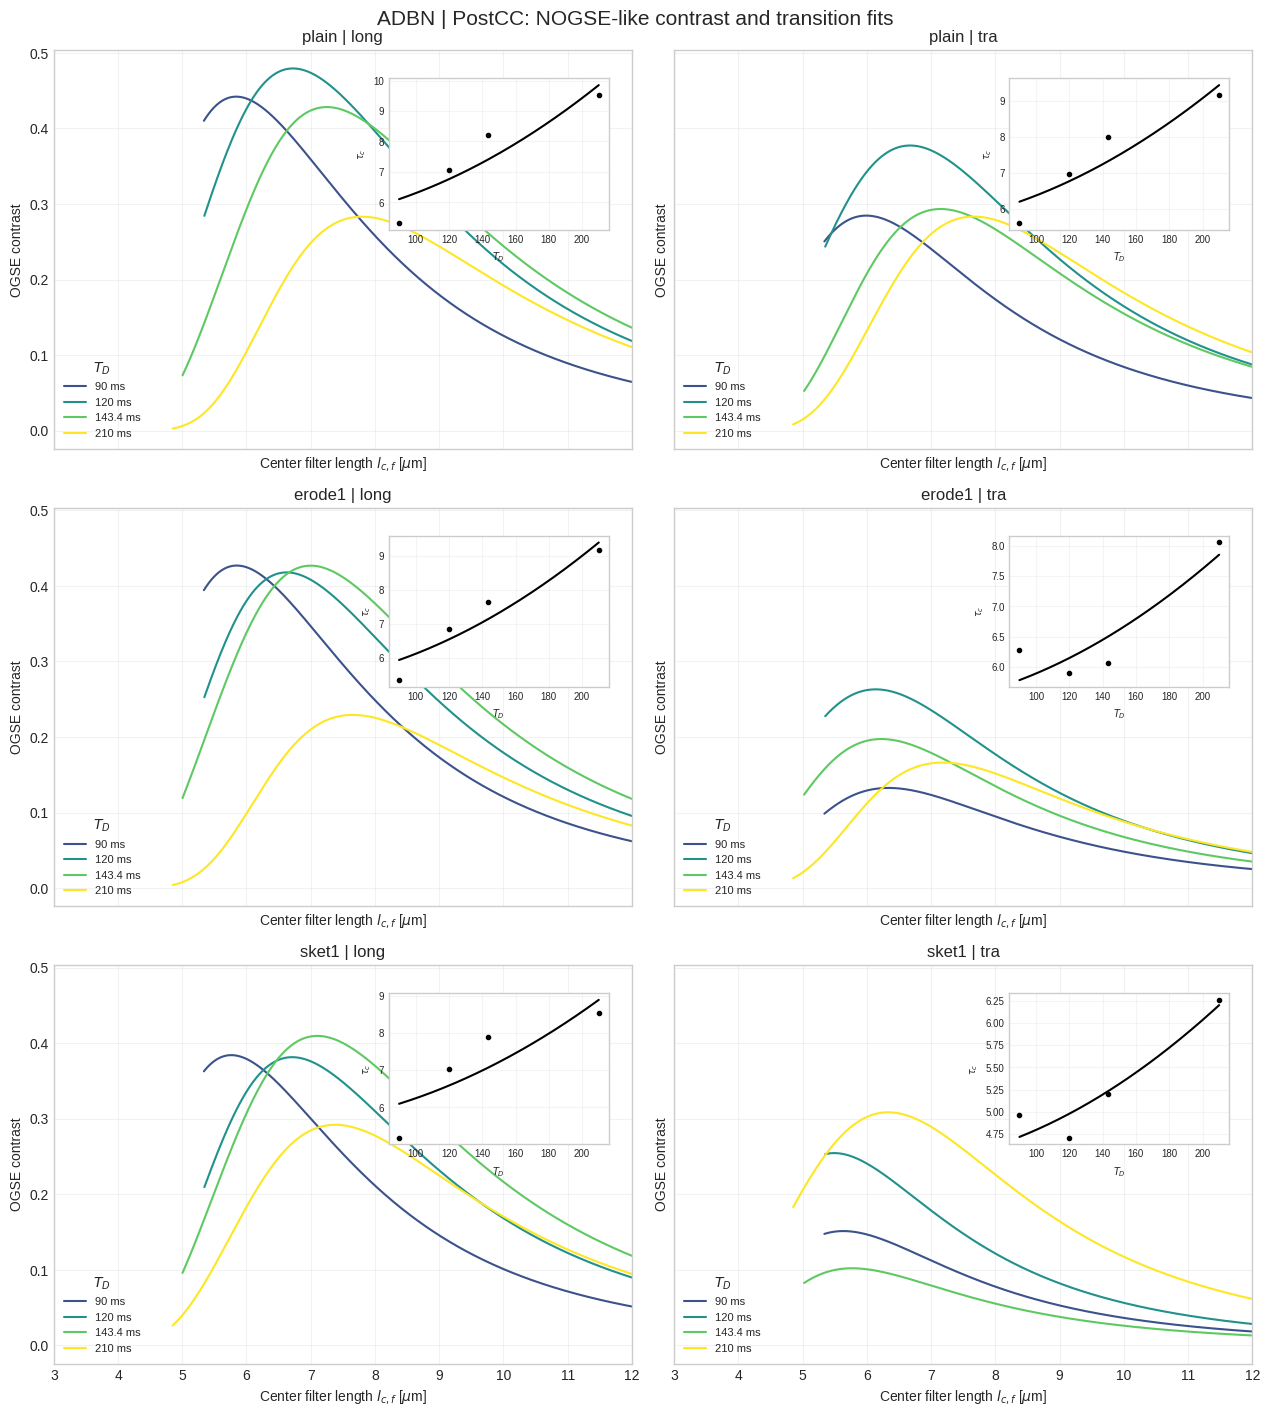

In [10]:
figure_2 = plot_contrast_lcf_grid(
    contrasts,
    contrast_fits,
    tc_data,
    tc_summary,
    variants=selected_variants,
    subject=EXAMPLE_SUBJECT,
    roi=EXAMPLE_ROI,
    directions=analysis_directions,
    lcf_limits_um=LCF_LIMITS_UM,
    output_path=OUTPUT_DIR / '02_contrast_vs_filtered_length.png' if SAVE_OUTPUTS else None,
)
plt.show()

## 8. Figure 3 analogue: regional $\delta$ and $\alpha$

The upper row shows the NOGSE-derived transition time $\delta$; the lower row shows the independent PGSE-derived $\alpha_{macro}$. Bars are arithmetic means across the valid subjects in each ROI/variant/direction cell and error bars are the standard error of that mean. Open markers retain every subject-level estimate, so the reader can distinguish a consistent variant shift from a bar driven by one subject.

All variants share axes within each direction. Only `presentation_ok` transition fits enter this figure, but the exclusion tables remain part of the output. A missing marker is missing/invalid data, not a zero. Because the valid subject count may differ after ROI loss or fit exclusion, paired differences in Section 10 are the correct basis for quantitative claims about segmentation effects.

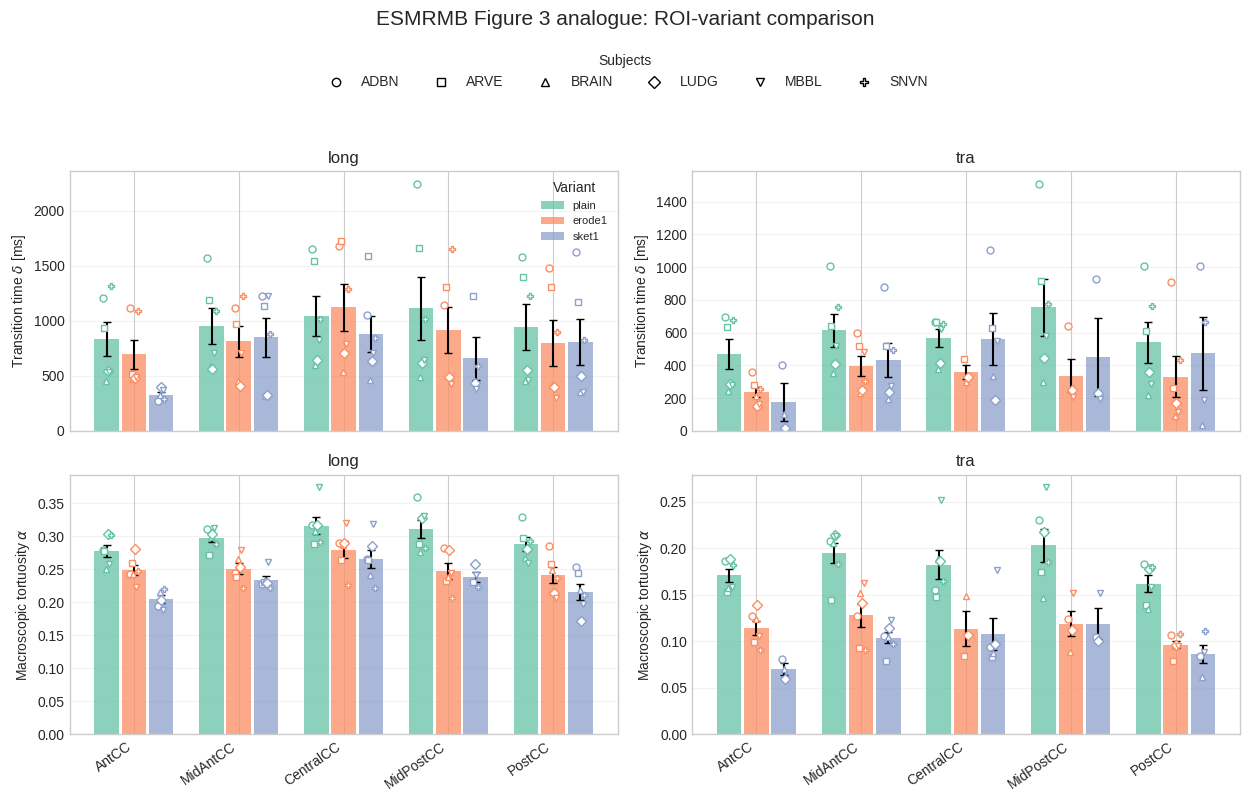

In [11]:
figure_3 = plot_metric_comparison(
    metrics_for_plots,
    variants=selected_variants,
    rois=analysis_rois,
    directions=analysis_directions,
    output_path=OUTPUT_DIR / '03_delta_alpha_by_region.png' if SAVE_OUTPUTS else None,
)
plt.show()

## 9. Figure 4 analogue: $\delta$ versus $\alpha$

Every point is one matched subject/ROI/direction estimate: x is the PGSE-derived $\alpha_{macro}$ and y is the NOGSE-derived transition time $\delta$. Color identifies the ROI and marker shape identifies the subject. Separate variant-by-direction panels prevent a change in ROI extraction from being hidden by overplotting.

This figure is descriptive: it shows clustering, outliers, subject consistency, and possible association between the two observables. It does not by itself establish correlation or causality. Any formal association should account for repeated measurements within subject, ROI, direction, and variant instead of treating all points as independent.

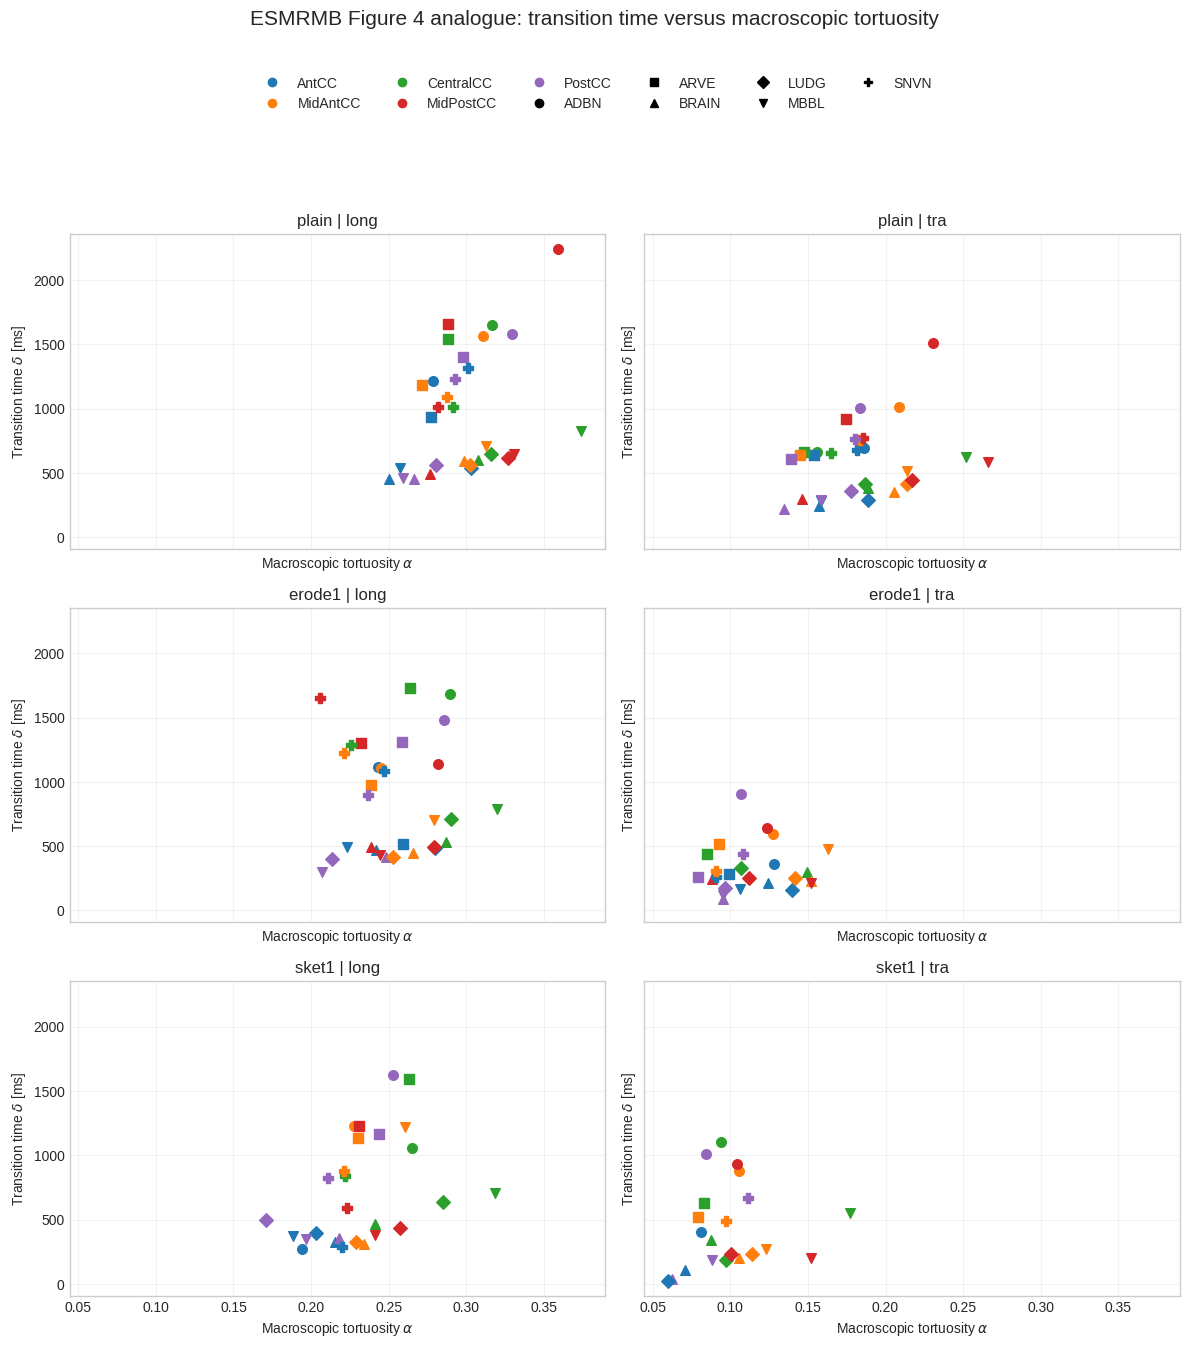

In [12]:
figure_4 = plot_alpha_delta_scatter(
    metrics_for_plots,
    variants=selected_variants,
    rois=analysis_rois,
    directions=analysis_directions,
    output_path=OUTPUT_DIR / '04_alpha_vs_delta.png' if SAVE_OUTPUTS else None,
)
plt.show()

## 10. Paired variant effects and export

Only matched subject/ROI/direction combinations enter paired differences. For metric $x$, the exported definitions are

$$\Delta x=x_{variant}-x_{reference}, \qquad \Delta x[\%]=100\frac{x_{variant}-x_{reference}}{x_{reference}}.$$

This pairing removes between-subject and between-ROI level differences from the segmentation comparison. Missing ROIs or invalid fits are never imputed, and the matched-case count is reported beside every mean difference. Percent differences can become unstable when the reference is near zero, so absolute and relative effects should be read together. These summaries are descriptive and do not replace a repeated-measures statistical model if inferential claims are required.

In [13]:
variant_differences = compare_with_reference_metrics(
    metrics_for_plots,
    reference_variant=REFERENCE_VARIANT,
)
variant_differences.insert(0, 'dataset', DATASET)
difference_summary = (
    variant_differences.groupby(['variant', 'direction'], as_index=False)
    .agg(
        matched_cases=('subj', 'size'),
        alpha_mean_difference=('alpha_macro_difference', 'mean'),
        alpha_mean_percent_difference=('alpha_macro_percent_difference', 'mean'),
        delta_mean_difference_ms=('delta_ms_difference', 'mean'),
        delta_mean_percent_difference=('delta_ms_percent_difference', 'mean'),
    )
)
difference_summary.insert(0, 'dataset', DATASET)
analysis_config = pd.DataFrame(
    [{
        'dataset': DATASET,
        'sequence': SEQUENCE,
        'dwi_level': DWI_LEVEL,
        'variants': ';'.join(selected_variants),
        'reference_variant': REFERENCE_VARIANT,
        'rois': ';'.join(analysis_rois),
        'directions': ';'.join(analysis_directions),
        'N_high': N_HIGH,
        'N_low': N_LOW,
        'D0_reference_m2_ms': D0_REFERENCE_M2_MS,
        'gradient_correction': APPLY_GRADIENT_CORRECTION,
        'contrast_construction': 'restricted_signal_fits_shared_C_resampled_common_gradient',
        'resample_grid_size': RESAMPLE_GRID_SIZE,
        'signal_tc_bounds_ms': ';'.join(map(str, SIGNAL_TC_BOUNDS_MS)),
        'rician_C_bounds': ';'.join(map(str, RICIAN_C_BOUNDS)),
        'excluded_td_ms': ';'.join(map(str, EXCLUDE_TD_MS)),
        'td_min_ms': TD_RANGE_MS[0],
        'td_max_ms': TD_RANGE_MS[1],
        'minimum_pseudohuber_r2': MIN_PSEUDOHUBER_R2_FOR_SUMMARY,
        'exclude_delta_boundary': EXCLUDE_DELTA_BOUNDARY_FROM_SUMMARY,
        'export_all_signal_contrast_panels': EXPORT_ALL_SIGNAL_CONTRAST_PANELS,
        'clean_batch_panel_dir': CLEAN_BATCH_PANEL_DIR,
        'batch_panel_dpi': BATCH_PANEL_DPI,
        'batch_panel_key': 'subj;sheet;roi;direction;td_ms',
    }]
)
display(difference_summary)

,dataset,variant,direction,matched_cases,alpha_mean_difference,alpha_mean_percent_difference,delta_mean_difference_ms,delta_mean_percent_difference
0,brains,erode1,long,30,-0.044396,-14.804189,-107.143236,-10.137258
1,brains,erode1,tra,25,-0.067969,-37.158660,-232.722785,-40.087482
2,brains,plain,long,30,0.000000,0.000000,0.000000,0.000000
3,brains,plain,tra,30,0.000000,0.000000,0.000000,0.000000
4,brains,sket1,long,27,-0.065119,-21.977753,-227.008103,-23.344123
5,brains,sket1,tra,21,-0.091715,-48.374643,-155.982259,-32.870860


In [14]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    analysis_config.to_csv(OUTPUT_DIR / 'analysis_config.csv', index=False)
    qc.to_csv(OUTPUT_DIR / 'master_qc.csv', index=False)
    coverage.to_csv(OUTPUT_DIR / 'coverage_vs_reference.csv', index=False)
    missing_rows.to_csv(OUTPUT_DIR / 'missing_master_rows.csv', index=False)
    contrasts.to_csv(OUTPUT_DIR / 'resampled_contrast.csv', index=False)
    contrast_fits.to_csv(OUTPUT_DIR / 'signal_pair_fit_summary.csv', index=False)
    tc_data.to_csv(OUTPUT_DIR / 'tc_peak_vs_td.csv', index=False)
    tc_summary.to_csv(OUTPUT_DIR / 'pseudohuber_fit_summary.csv', index=False)
    fit_exclusions.to_csv(OUTPUT_DIR / 'pseudohuber_fit_exclusions.csv', index=False)
    metrics.to_csv(OUTPUT_DIR / 'alpha_delta_subject_summary.csv', index=False)
    variant_differences.to_csv(OUTPUT_DIR / 'variant_differences_vs_reference.csv', index=False)
    difference_summary.to_csv(OUTPUT_DIR / 'variant_difference_summary.csv', index=False)
    print(f'Figures and audit tables saved under: {OUTPUT_DIR}')

Figures and audit tables saved under: /mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/esmrmb_variant_comparison/brains/den_gr-topup


## 11. Output map, interpretation, and limitations

The output root is `notebooks/outputs/esmrmb_variant_comparison/<dataset>/<dwi-level>/`. Presentation-level figures `00`–`04`, configuration, QC, fitted parameters, resampled curves, and paired differences are written directly there. The exhaustive Section 6 gallery is organized as

```text
06_all_signal_contrast_panels/
├── manifest.csv
└── sub-<subject>/
    └── sheet-<acquisition>/
        └── roi-<ROI>__dir-<direction>__td-<time>ms.png
```

Each gallery image contains every selected ROI variant as a row. `manifest.csv` is the authoritative index: it stores the exact scientific key, relative image path, successful variants, missing/failed variants, and whether all selected variants were available. With cleanup enabled, rerunning removes older gallery PNGs, its older manifest, thumbnail metadata, and obsolete empty subdirectories before regenerating them. Subject and sheet remain as directories; ROI, direction, and diffusion time are encoded in the filename to keep the gallery shallow.

Before using the results in a presentation:

- Report the coverage audit and any ROI/acquisition combinations missing from a variant. A segmentation that removes an ROI changes the estimand and the matched sample.
- Inspect Section 6 curves, especially low branch-specific $R^2$, a shared $C$ at its bound, a peak at the grid boundary, or obvious systematic residuals. The resampled grid makes a continuous comparison possible but does not create new experimental information.
- Inspect all pseudo-Huber exclusions and boundary fits; optimizer convergence alone is not biological validity, and $\delta$ may be weakly identified when the measured $T_D$ range does not span the crossover.
- Base segmentation-effect claims on `variant_differences_vs_reference.csv`, which contains matched cases, and always report the matched-case count. Group bars with different valid subjects are descriptive.
- Keep the dataset-specific $D_0$, gradient calibration, N pair, time exclusions, bounds, directions, and ROI definitions with the exported figures. Changing any of them changes the analysis definition.
- Treat $l_{c,f}$, $\tau_{c,peak}$, $\alpha$, and $\delta$ as model-dependent observables. Their uncertainty includes more than the local optimizer covariance: segmentation, calibration, model mismatch, fixed $D_0$, finite gradient sampling, and repeated measurements can all contribute.
- Do not interpret brain-versus-phantom differences as tissue effects until acquisition protocols, temperature/reference diffusivity, ROI definitions, direction conventions, and available diffusion times are demonstrably comparable.

Brain and phantom runs are written to separate dataset/DWI-level directories with compatible schemas. After the phantom master and alpha-summary tables exist, set `DATASET='phantoms'`, review its profile constants and dimensions, and rerun from the top. No contrast or fit logic needs to change.